In [1]:
import sys
!{sys.executable} -m pip install pacmap umap-learn scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pickle
import numba

from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import StratifiedKFold, LeaveOneOut
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import make_pipeline
from collections import Counter
from numpy.random import default_rng

import numpy as np
import numba

import time
from pathlib import Path

import torch
import torch.nn as nn

from LatentDistanceModel import LatentDistanceModel
from utils import (
    get_initial_parameters,
    load_MNIST,
    load_s_hole,
    load_swissroll,
    load_mammoth,
    sample_edges,
)

import numpy as np
import pacmap
import umap
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [3]:
@numba.njit()
def euclid_dist(x1, x2):
    result = 0.0
    for i in range(x1.shape[0]):
        result += (x1[i] - x2[i]) ** 2
    return np.sqrt(result)

def score(X, Y, i,j,k):
    yij = euclid_dist(Y[i], Y[j])
    yik = euclid_dist(Y[i], Y[k])
    if yik < yij:
        return 1
    else:
        return 0

def score_largely(X, Y, i,j,k):
    xij = euclid_dist(X[i], X[j])
    xik = euclid_dist(X[i], X[k])
    yij = euclid_dist(Y[i], Y[j])
    yik = euclid_dist(Y[i], Y[k])
    if (xik-xij)/(xik+1e-15) < 0.2: # when the triplet is less important in high-dim space
        if (yij-yik)/(yik+1e-15) < 0.2: # no violation or slight violation
            return 0
        else:
            return 1
    else: # when the triplet is important in high-dim space
        if yij < yik:
            return 0
        else:
            return 1



def _normalize_labels(y, n_samples=None):
    if y is None:
        if n_samples is None:
            return None
        return np.zeros(n_samples, dtype=int)
    return np.asarray(y).reshape(-1)

def knn_clf(nbr_vec, y):
    '''
    Helper function to generate knn classification result.
    '''
    nbr_vec = np.asarray(nbr_vec).reshape(-1)
    y_vec = _normalize_labels(y)[nbr_vec]
    c = Counter(y_vec)
    return c.most_common(1)[0][0]
    
def knn_eval(X, y, n_neighbors=1):
    '''
    This is a function that is used to evaluate the lower dimension embedding.
    An accuracy is calculated by an k-nearest neighbor classifier.
    Input:
        X: A numpy array with the shape [N, k]. The lower dimension embedding
           of some dataset. Expected to have some clusters.
        y: A numpy array with the shape [N, 1]. The labels of the original
           dataset.
        kwargs: Any keyword argument that is send into the knn clf.
    Output:
        acc: The avg accuracy generated by the clf, using leave one out cross val.
    '''
    y = _normalize_labels(y, n_samples=X.shape[0])
    sum_acc = 0
    max_acc = X.shape[0]
    # Train once, reuse multiple times
    nbrs = NearestNeighbors(n_neighbors=n_neighbors+1).fit(X)
    distances, indices = nbrs.kneighbors(X)
    indices = indices [:, 1:]
    distances = distances[:, 1:]
    for i in range(X.shape[0]):
        result = knn_clf(indices[i], y)
        if result == y[i]:
            sum_acc += 1
    avg_acc = sum_acc / max_acc
    return avg_acc

def knn_eval_series(X, y, n_neighbors_list=[1, 3, 5, 10, 15, 20, 25, 30]):
    '''
    This is a function that is used to evaluate the lower dimension embedding.
    An accuracy is calculated by an k-nearest neighbor classifier.
    A series of accuracy will be calculated for the given n_neighbors.
    Input:
        X: A numpy array with the shape [N, k]. The lower dimension embedding
           of some dataset. Expected to have some clusters.
        y: A numpy array with the shape [N, 1]. The labels of the original
           dataset.
        n_neighbors_list: A list of int.
        kwargs: Any keyword argument that is send into the knn clf.
    Output:
        accs: The avg accuracy generated by the clf, using leave one out cross val.
    '''
    avg_accs = []
    for n_neighbors in n_neighbors_list:
        avg_acc = knn_eval(X, y, n_neighbors)
        avg_accs.append(avg_acc)
    return avg_accs

def faster_knn_eval_series(X, y, n_neighbors_list=[1, 3, 5, 10, 15, 20, 25, 30]):
    '''
    This is a function that is used to evaluate the lower dimension embedding.
    An accuracy is calculated by an k-nearest neighbor classifier.
    A series of accuracy will be calculated for the given n_neighbors.
    Input:
        X: A numpy array with the shape [N, k]. The lower dimension embedding
           of some dataset. Expected to have some clusters.
        y: A numpy array with the shape [N, 1]. The labels of the original
           dataset.
        n_neighbors_list: A list of int.
        kwargs: Any keyword argument that is send into the knn clf.
    Output:
        accs: The avg accuracy generated by the clf, using leave one out cross val.
    '''
    avg_accs = []
    max_acc = X.shape[0]
    # Train once, reuse multiple times
    nbrs = NearestNeighbors(n_neighbors=n_neighbors_list[-1]+1).fit(X)
    distances, indices = nbrs.kneighbors(X)
    indices = indices [:, 1:]
    distances = distances[:, 1:]
    for n_neighbors in n_neighbors_list:
        sum_acc = 0
        for i in range(X.shape[0]):
            indices_temp = indices[:, :n_neighbors]
            result = knn_clf(indices_temp[i], y)
            if result == y[i]:
                sum_acc += 1
        avg_acc = sum_acc / max_acc
        avg_accs.append(avg_acc)
    return avg_accs


def _as_numpy(arr):
    # Allow NumPy operations even when inputs are torch tensors.
    if hasattr(arr, "detach"):
        arr = arr.detach()
    if hasattr(arr, "cpu"):
        arr = arr.cpu()
    return np.asarray(arr)

def centroid_triplet_eval(X, X_new, y):
    '''
    This is a function that is used to evaluate the lower dimension embedding.
    An triplet satisfaction score is calculated by evaluating how many triplets
    of cluster centroids have been violated.
    Input:
        X: A numpy array with the shape [N, p]. The higher dimension embedding
           of some dataset. Expected to have some clusters.
        X_new: A numpy array with the shape [N, k]. The lower dimension embedding
               of some dataset. Expected to have some clusters as well.
        y: A numpy array with the shape [N, 1]. The labels of the original
           dataset. Used to identify clusters
    Output:
        acc: The score generated by the algorithm.
    '''  

    X = _as_numpy(X)
    X_new = _as_numpy(X_new)
    y = _normalize_labels(y)

    cluster_mean_ori, cluster_mean_new = [], []
    categories = np.unique(y)
    if len(categories) < 2:
        return 1.0
    num_cat = len(categories)
    mask = np.mask_indices(num_cat, np.tril, -1)
    for i in range(num_cat):
        label = categories[i]
        X_clus_ori = X[y == label]
        X_clus_new = X_new[y == label]
        cluster_mean_ori.append(np.mean(X_clus_ori, axis = 0))
        cluster_mean_new.append(np.mean(X_clus_new, axis = 0))
    cluster_mean_ori = np.array(cluster_mean_ori)
    cluster_mean_new = np.array(cluster_mean_new)
    ori_dist = euclidean_distances(cluster_mean_ori)[mask]
    new_dist = euclidean_distances(cluster_mean_new)[mask]
    dist_agree = 0. # two distance agrees
    dist_all = 0. # count
    for i in range(len(ori_dist)):
        for j in range(i+1, len(ori_dist)):
            if ori_dist[i] > ori_dist[j] and new_dist[i] > new_dist[j]:
                dist_agree += 1
            elif ori_dist[i] <= ori_dist[j] and new_dist[i] <= new_dist[j]:
                dist_agree += 1
            dist_all += 1
    return dist_agree/dist_all

def faster_centroid_triplet_eval(X, X_new, y):
    '''
    This is a function that is used to evaluate the lower dimension embedding.
    An triplet satisfaction score is calculated by evaluating how many triplets
    of cluster median centroids have been violated.
    Input:
        X: A numpy array with the shape [N, p]. The higher dimension embedding
           of some dataset. Expected to have some clusters.
        X_new: A numpy array with the shape [N, k]. The lower dimension embedding
               of some dataset. Expected to have some clusters as well.
        y: A numpy array with the shape [N, 1]. The labels of the original
           dataset. Used to identify clusters
    Output:
        acc: The score generated by the algorithm.
    '''    
    cluster_mean_ori, cluster_mean_new = [], []
    y = _normalize_labels(y)
    categories = np.unique(y)
    if len(categories) < 2:
        return 1.0
    num_cat = len(categories)
    mask = np.mask_indices(num_cat, np.tril, -1)
    for i in range(num_cat):
        label = categories[i]
        X_clus_ori = X[y == label]
        X_clus_new = X_new[y == label]
        cluster_mean_ori.append(np.median(X_clus_ori, axis = 0))
        cluster_mean_new.append(np.median(X_clus_new, axis = 0))
    cluster_mean_ori = np.array(cluster_mean_ori)
    cluster_mean_new = np.array(cluster_mean_new)
    ori_dist = euclidean_distances(cluster_mean_ori)[mask]
    new_dist = euclidean_distances(cluster_mean_new)[mask]
    dist_agree = 0. # two distance agrees
    dist_all = 0. # count
    for i in range(len(ori_dist)):
        for j in range(i+1, len(ori_dist)):
            if ori_dist[i] > ori_dist[j] and new_dist[i] > new_dist[j]:
                dist_agree += 1
            elif ori_dist[i] <= ori_dist[j] and new_dist[i] <= new_dist[j]:
                dist_agree += 1
            dist_all += 1
    return dist_agree/dist_all

def random_triplet_eval(X, X_new, y):
    '''
    This is a function that is used to evaluate the lower dimension embedding.
    An triplet satisfaction score is calculated by evaluating how many randomly
    selected triplets have been violated. Each point will generate 5 triplets.
    Input:
        X: A numpy array with the shape [N, p]. The higher dimension embedding
           of some dataset. Expected to have some clusters.
        X_new: A numpy array with the shape [N, k]. The lower dimension embedding
               of some dataset. Expected to have some clusters as well.
        y: A numpy array with the shape [N, 1]. The labels of the original
           dataset. Used to identify clusters
    Output:
        acc: The score generated by the algorithm.
    '''    

    # Sampling Triplets
    # Five triplet per point
    anchors = np.arange(X.shape[0])
    rng = default_rng()
    triplets = rng.choice(anchors, (X.shape[0], 5, 2))
    triplet_labels = np.zeros((X.shape[0], 5))
    anchors = anchors.reshape((-1, 1, 1))
    
    # Calculate the distances and generate labels
    b = np.broadcast(anchors, triplets)
    distances = np.empty(b.shape)
    distances.flat = [np.linalg.norm(X[u] - X[v]) for (u,v) in b]
    labels = distances[:, :, 0] < distances[: , :, 1]

    
    # Calculate distances for LD
    b = np.broadcast(anchors, triplets)
    distances_l = np.empty(b.shape)
    distances_l.flat = [np.linalg.norm(X_new[u] - X_new[v]) for (u,v) in b]
    pred_vals = distances_l[:, :, 0] < distances_l[:, :, 1]
    correct = np.sum(pred_vals == labels)
    acc = correct/X.shape[0]/5
    return acc


def evaluate_output_non_svm(X, X_new, y, name, baseline=False, labelled=True):
    results = {}
    results['name'] = name
    if labelled:
        if baseline:
            baseline_knn_accs = knn_eval_series(X, y)
            results['baseline_knn'] = baseline_knn_accs
        knn_accs = knn_eval_series(X_new, y)
        cte_acc = centroid_triplet_eval(X, X_new, y)
        results['knn'] = knn_accs
        results['cte'] = cte_acc
    rte_acc = random_triplet_eval(X, X_new, y)
    results['rte'] = rte_acc
    return results



In [4]:
def continuous_to_integer_bins(t):
    n_bins = int(np.floor(t.max()) - np.ceil(t.min())) + 1
    return np.digitize(t, bins=np.linspace(t.min(), t.max(), num=n_bins))

# Load data
dataset = "mnist"
discretize = True

match dataset:
    case "swissroll":
        samples = 5000
        X, t = load_swissroll(n_samples=samples)
        if discretize == True and 't' in locals():
            y = continuous_to_integer_bins(t)  # Er en måde at få reelle labels ud af kontinuerte data, som er nødvendigt for at kunne evaluere på triplet testene.
        else:
            y = t

    case "s_hole":
        samples = 5000
        X, t = load_s_hole(n_samples=samples)
        if discretize == True and 't' in locals():
            y = continuous_to_integer_bins(t)  # Er en måde at få reelle labels ud af kontinuerte data, som er nødvendigt for at kunne evaluere på triplet testene.
        else:
            y = t

    case "mammoth":
        X, y = load_mammoth(subset_percent=0.01)  # y= None
        discretize = False
        samples = X.shape[0]
    case "mnist":
        X, y = load_MNIST(subset_percent=0.1)
        discretize = False
        samples = X.shape[0]

        # t == kontinuerte labels, og y == diskrete labels

if isinstance(X, torch.Tensor):
    X_numpy = X.numpy()
else:
    X_numpy = X
N, D = X.shape
print('data rows,cols:', N, D)





data rows,cols: 7000 784


In [5]:
fitting_k_list = [20]
sigma_q_list = [20]

In [6]:
# !!!!!!!!!!!!    LDM    !!!!!!!!!!!!

ldm_embeddings = []

for i, sigma_q in enumerate(sigma_q_list):
    # %% HYPERPARAMETER
    k = 20
    lr = 0.05
    weight_decay = (1e-4)/2
    negative_ratio = 10
    positive_edge_weight = 6.0
    epochs = 150
    save_timeline = False
    


    # %% MODEL
    t_edge = t_forward = t_backward = t_step = 0.0
    t0_total = time.perf_counter()


    t0 = time.perf_counter()
    knn_indices, sigma = get_initial_parameters(X, k_neighbors=k, sigma_q=sigma_q)
    t_alldistances = time.perf_counter() - t0

    ldm = LatentDistanceModel(
        data = X,
        output_dimension=2,
        data_labels=y,
        initialization="random",
    )

    optimizer = torch.optim.Adam(ldm.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss(reduction="none")
    if save_timeline:
        timeline_dir = Path(f"timelines/{dataset}")
        # timeline_dir.mkdir(parents=True, exist_ok=True)
        run_name = "_".join(
            [
                f"k={k}",
                f"samples={samples}",
                f"negative_ratio={negative_ratio}",
                f"sigma_q={sigma_q}",
                f"lr={lr}",
                f"weight_decay={weight_decay}",
                f"epochs={epochs}",
            ]
        )
        model_folder = timeline_dir / run_name
        model_folder.mkdir(parents=True, exist_ok=True)



    # %% TRAINING
    for epoch in range(epochs+1):
        optimizer.zero_grad()

        t0 = time.perf_counter()
        edges, edge_distances, targets = sample_edges(X = X, knn_indices=knn_indices, negative_ratio=negative_ratio, sigma=sigma)
        t_edge += time.perf_counter() - t0

        t0 = time.perf_counter()
        logits = ldm(edges)
        per_edge_loss = loss_fn(logits, targets)
        edge_weights = torch.ones_like(targets)
        edge_weights[:, :k] = positive_edge_weight
        loss = (per_edge_loss * edge_weights).sum() / edge_weights.sum()
        t_forward += time.perf_counter() - t0

        t0 = time.perf_counter()
        loss.backward()
        t_backward += time.perf_counter() - t0

        t0 = time.perf_counter()
        optimizer.step()
        t_step += time.perf_counter() - t0

        if epoch % 10 == 0:
            print(
                f"Epoch {epoch:4d} | Loss: {loss.item():.4f} | "
                # f"Alpha: {ldm.alpha.item():.4f} | ",
            )
            if save_timeline:
                elapsed = time.perf_counter() - t0_total
                save_path = model_folder / f"epoch={epoch}_t={elapsed:.3f}s.png"
                ldm.visualize(datatype=dataset, show=True, save_path=save_path)



    # %% Information
    total_time = time.perf_counter() - t0_total
    diff_time = total_time - (t_alldistances + t_edge + t_forward + t_backward + t_step)


    lines = []
    lines.append(f"--- Time breakdown {dataset} ---")
    lines.append(f"Hyperparams: {k=}, {negative_ratio=}, {samples=}, {epochs=}")
    lines.append(f"Total Time:  {total_time:.3f}s")
    lines.append(f"edge sampling:  {t_edge:.3f}s  ({t_edge / total_time * 100:.1f}%)")
    lines.append(f"forward pass:   {t_forward:.3f}s  ({t_forward / total_time * 100:.1f}%)")
    lines.append(f"backward pass:  {t_backward:.3f}s  ({t_backward / total_time * 100:.1f}%)")
    lines.append(f"optimizer step: {t_step:.3f}s  ({t_step / total_time * 100:.1f}%)")
    lines.append(f"Dense Distance Matrix(NxN): {t_alldistances:.3f}s  ({t_alldistances / total_time * 100:.1f}%)")
    lines.append(f"Other: {diff_time:.3f}s  ({diff_time / total_time * 100:.1f}%)")
    print(*lines, sep='\n')

    if save_timeline:
        timing_path = model_folder / "timings.txt"
        with timing_path.open("w") as f:
            f.write("\n".join(lines))

    ldm_embedding = ldm.Z.weight.detach().cpu().numpy()
    ldm_embeddings.append(ldm_embedding)


Epoch    0 | Loss: 0.6813 | 
Epoch   10 | Loss: 0.6668 | 
Epoch   20 | Loss: 0.6619 | 
Epoch   30 | Loss: 0.6609 | 
Epoch   40 | Loss: 0.6605 | 
Epoch   50 | Loss: 0.6605 | 
Epoch   60 | Loss: 0.6605 | 
Epoch   70 | Loss: 0.6604 | 
Epoch   80 | Loss: 0.6605 | 
Epoch   90 | Loss: 0.6605 | 
Epoch  100 | Loss: 0.6604 | 
Epoch  110 | Loss: 0.6604 | 
Epoch  120 | Loss: 0.6605 | 
Epoch  130 | Loss: 0.6604 | 
Epoch  140 | Loss: 0.6604 | 
Epoch  150 | Loss: 0.6605 | 
--- Time breakdown mnist ---
Hyperparams: k=20, negative_ratio=10, samples=7000, epochs=150
Total Time:  476.865s
edge sampling:  466.735s  (97.9%)
forward pass:   3.659s  (0.8%)
backward pass:  5.536s  (1.2%)
optimizer step: 0.101s  (0.0%)
Dense Distance Matrix(NxN): 0.810s  (0.2%)
Other: 0.024s  (0.0%)


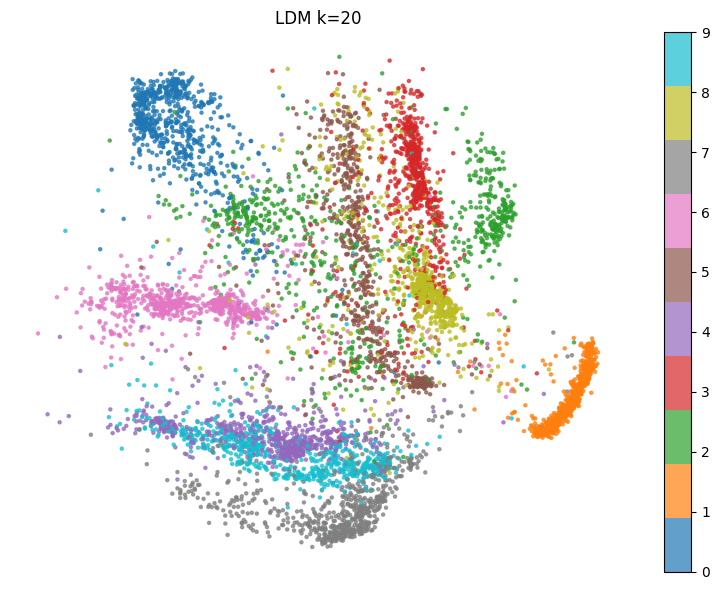

Mean(alpha_i + alpha_j):  -0.190109
std(alpha_i + alpha_j):  0.133765
Mean target_prob (knn):    0.531583
Mean target_prob (neg):    0.328975


In [7]:
# Visualization for LDM results (single run)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
labels = np.zeros(X.shape[0]) if y is None else np.asarray(y).reshape(-1)

embedding = ldm_embeddings[0]
sc = ax.scatter(*embedding.T, c=labels, cmap="tab10", s=5, alpha=0.7)
ax.set_title(f"LDM k={fitting_k_list[0]}")
ax.axis("off")

plt.colorbar(sc, ax=ax)
plt.tight_layout()
plt.show()


# Summarize the learned alpha values and target probabilities from the current LDM run.
# `alpha_i + alpha_j` is the pairwise term used in the model logits.
if 'ldm' not in globals():
    raise NameError('ldm is not defined yet. Run the training cell first.')
if 'knn_indices' not in globals() or 'sigma' not in globals() or 'negative_ratio' not in globals():
    raise NameError('knn_indices, sigma, or negative_ratio is not defined yet. Run the training cell first.')

alpha_values = ldm.alpha.detach().cpu().numpy().reshape(-1)
alpha_mean = float(alpha_values.mean())
alpha_sum = float(alpha_values.sum())
pairwise_alpha_mean = float((alpha_values[:, None] + alpha_values[None, :]).mean())

edges, edge_distances, target_probabilities = sample_edges(
    X=X,
    knn_indices=knn_indices,
    negative_ratio=negative_ratio,
    sigma=sigma,
)

k = knn_indices.shape[1]
knn_target_prob_mean = float(target_probabilities[:, :k].mean().item())
negative_target_prob_mean = float(target_probabilities[:, k:].mean().item())

print(f"Mean(alpha_i + alpha_j):  {pairwise_alpha_mean:.6f}")
print(f"std(alpha_i + alpha_j):  {(alpha_values[:, None] + alpha_values[None, :]).std():.6f}")
print(f"Mean target_prob (knn):    {knn_target_prob_mean:.6f}")
print(f"Mean target_prob (neg):    {negative_target_prob_mean:.6f}")

In [10]:
ldm_k1_knn_results = knn_eval(ldm_embeddings[0], y, n_neighbors=5)
ldm_k1_ran_triplet_results = random_triplet_eval(X, ldm_embeddings[0], y)
print(f"LDM k={fitting_k_list[0]} KNN-5 Accuracy: {ldm_k1_knn_results:.4f}")
print(f"LDM k={fitting_k_list[0]} Random Triplet Accuracy: {ldm_k1_ran_triplet_results:.4f}")

LDM k=20 KNN-5 Accuracy: 0.8031
LDM k=20 Random Triplet Accuracy: 0.6663


In [ ]:
#Visualization for LDM results
fig, axes = plt.subplots(1, len(sigma_q_list), figsize=(30, 5))
labels = np.zeros(X.shape[0]) if y is None else np.asarray(y).reshape(-1)

for ax, (title, embedding) in zip(axes, [
    (f"LDM parameter value:{sigma_q_list[0]}", ldm_embeddings[0]),
    (f"LDM parameter value:{sigma_q_list[1]}", ldm_embeddings[1]),
    (f"LDM parameter value:{sigma_q_list[2]}", ldm_embeddings[2]),
    (f"LDM parameter value:{sigma_q_list[3]}", ldm_embeddings[3]),
    (f"LDM parameter value:{sigma_q_list[4]}", ldm_embeddings[4]),
]):
    sc = ax.scatter(*embedding.T, c=labels, cmap="tab10", s=5, alpha=0.7)
    ax.set_title(title)
    ax.axis("off")

plt.colorbar(sc, ax=axes[-1])
plt.tight_layout()
plt.show()

In [ ]:
ldm_k1_knn_results = knn_eval(ldm_embeddings[0], y, n_neighbors=5)
ldm_k2_knn_results = knn_eval(ldm_embeddings[1], y, n_neighbors=5)
ldm_k3_knn_results = knn_eval(ldm_embeddings[2], y, n_neighbors=5)
ldm_k4_knn_results = knn_eval(ldm_embeddings[3], y, n_neighbors=5)
ldm_k5_knn_results = knn_eval(ldm_embeddings[4], y, n_neighbors=5)

for i, k in enumerate(sigma_q_list):
    print(f"LDM with parameter value {sigma_q_list[i]} has knn accuracy: {eval(f'ldm_k{i+1}_knn_results'):.4f}")

ldm_k1_ran_triplet_results = random_triplet_eval(X, ldm_embeddings[0], y)
ldm_k2_ran_triplet_results = random_triplet_eval(X, ldm_embeddings[1], y)
ldm_k3_ran_triplet_results = random_triplet_eval(X, ldm_embeddings[2], y)
ldm_k4_ran_triplet_results = random_triplet_eval(X, ldm_embeddings[3], y)
ldm_k5_ran_triplet_results = random_triplet_eval(X, ldm_embeddings[4], y)
for i, sigma_q in enumerate(sigma_q_list):
    print(f"LDM with parameter value {sigma_q} has random triplet accuracy: {eval(f'ldm_k{i+1}_ran_triplet_results'):.4f}")